# velocity dipersion

Stars used: 679


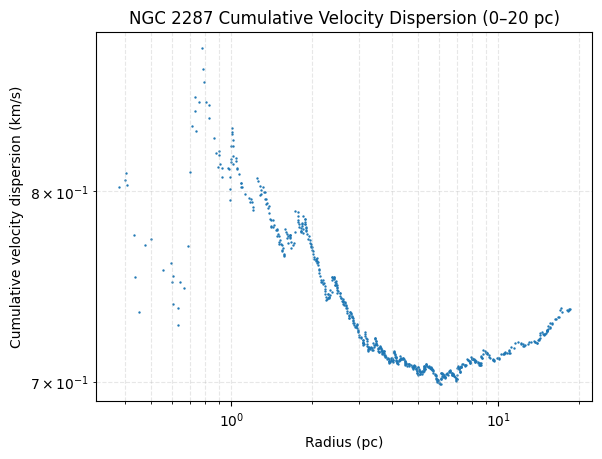

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# =====================================================
# LOAD DATA
# =====================================================

df = pd.read_csv("/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_2287_final.csv")

# =====================================================
# CLUSTER PARAMETERS
# =====================================================

ra0_deg  = 101.489724
dec0_deg = -20.721056

distance_pc = 641

ra0  = np.deg2rad(ra0_deg)
dec0 = np.deg2rad(dec0_deg)

# =====================================================
# COMPUTE PROJECTED RADIUS (pc)
# =====================================================

ra  = np.deg2rad(df["ra"].values)
dec = np.deg2rad(df["dec"].values)

delta_ra  = (ra - ra0) * np.cos(dec0)
delta_dec = (dec - dec0)

theta = np.sqrt(delta_ra**2 + delta_dec**2)
df["r_pc"] = theta * distance_pc

# =====================================================
# MEMBERSHIP + RADIAL CUT
# =====================================================

df = df[df["cluster_membership"] > 0.96].copy()
df = df[df["r_pc"] <= 20].copy()

print("Stars used:", len(df))

# =====================================================
# SORT BY RADIUS
# =====================================================

df = df.sort_values("r_pc").reset_index(drop=True)

r = df["r_pc"].values

# =====================================================
# PROPER MOTION → VELOCITY (km/s)
# =====================================================

k = 4.74047e-3 * distance_pc

v_ra  = df["pmra"].values  * k
v_dec = df["pmdec"].values * k

err_ra  = df["pmra_error"].values  * k
err_dec = df["pmdec_error"].values * k

# =====================================================
# CUMULATIVE DISPERSION
# =====================================================

sigma_cum = []

# need at least few stars for stable std
min_stars = 10

for i in range(min_stars, len(r)):

    v_ra_in  = v_ra[:i]
    v_dec_in = v_dec[:i]

    err_ra_in  = err_ra[:i]
    err_dec_in = err_dec[:i]

    # observed dispersion
    sig_ra  = np.std(v_ra_in,  ddof=1)
    sig_dec = np.std(v_dec_in, ddof=1)

    # subtract measurement variance
    err_ra2  = np.mean(err_ra_in**2)
    err_dec2 = np.mean(err_dec_in**2)

    sig_ra2_intr  = max(sig_ra**2  - err_ra2,  0)
    sig_dec2_intr = max(sig_dec**2 - err_dec2, 0)

    sigma_total = np.sqrt(sig_ra2_intr + sig_dec2_intr)
    sigma_cum.append(sigma_total)

r_cum = r[min_stars:]

# =====================================================
# PLOT
# =====================================================


plt.scatter(r_cum, sigma_cum, s=0.5)   # s controls point size

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Radius (pc)")
plt.ylabel("Cumulative velocity dispersion (km/s)")
plt.title("NGC 2287 Cumulative Velocity Dispersion (0–20 pc)")

plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()

# Trying to apply the velocity dispersion analysis to all 21 clusters using the re-estimated centres, along with the corresponding distances and membership thresholds adopted from Anindya’s paper.


Stars used: 66


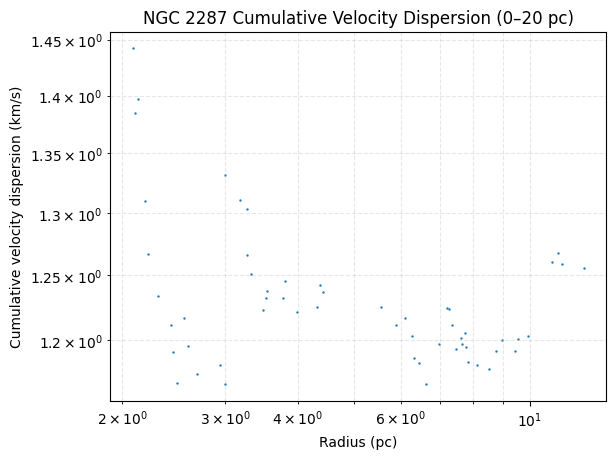

In [81]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# =====================================================
# LOAD DATA
# =====================================================

df1 = pd.read_csv("/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_7789_final.csv")

# =====================================================
# CLUSTER PARAMETERS
# =====================================================

ra0_deg  = 0.114752085
dec0_deg = 56.726
distance_pc = 2100

ra0  = np.deg2rad(ra0_deg)
dec0 = np.deg2rad(dec0_deg)

# =====================================================
# COMPUTE PROJECTED RADIUS (pc)
# =====================================================

ra  = np.deg2rad(df1["ra"].values)
dec = np.deg2rad(df1["dec"].values)

delta_ra  = (ra - ra0) * np.cos(dec0)
delta_dec = (dec - dec0)

theta = np.sqrt(delta_ra**2 + delta_dec**2)
df1["r_pc"] = theta * distance_pc

# =====================================================
# MEMBERSHIP + RADIAL CUT
# =====================================================

df1 = df1[df1["cluster_membership"] > 0.96].copy()
df1 = df1[df1["r_pc"] <= 20].copy()

print("Stars used:", len(df1))

df1 = df1.sort_values("r_pc").reset_index(drop=True)

r = df1["r_pc"].values

# =====================================================
# PROPER MOTION → VELOCITY
# =====================================================

k = 4.74047e-3 * distance_pc

v_ra  = df1["pmra"].values  * k
v_dec = df1["pmdec"].values * k

err_ra  = df1["pmra_error"].values  * k
err_dec = df1["pmdec_error"].values * k

# =====================================================
# CUMULATIVE DISPERSION
# =====================================================

sigma_cum = []
min_stars = 10

for i in range(min_stars, len(r)):

    sig_ra  = np.std(v_ra[:i],  ddof=1)
    sig_dec = np.std(v_dec[:i], ddof=1)

    err_ra2  = np.mean(err_ra[:i]**2)
    err_dec2 = np.mean(err_dec[:i]**2)

    sig_ra2_intr  = max(sig_ra**2  - err_ra2,  0)
    sig_dec2_intr = max(sig_dec**2 - err_dec2, 0)

    sigma_total = np.sqrt(sig_ra2_intr + sig_dec2_intr)
    sigma_cum.append(sigma_total)

r_cum = r[min_stars:]

plt.scatter(r_cum, sigma_cum, s=0.5)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Radius (pc)")
plt.ylabel("Cumulative velocity dispersion (km/s)")
plt.title("NGC 2287 Cumulative Velocity Dispersion (0–20 pc)")
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()

In [82]:
print("Processing:", cluster_name)
print("Matched centre label:", row["Cluster"])
print("RA centre:", ra0_deg)
print("Mean RA of stars:", df["ra"].mean())
print("DEC centre:", dec0_deg)
print("Mean DEC of stars:", df["dec"].mean())

Processing: Ngc 7789
Matched centre label: NGC 7789
RA centre: 0.114752085
Mean RA of stars: 0.11475208533608434
DEC centre: 56.726
Mean DEC of stars: 56.74386910089307


In [76]:
print("Min radius:", df["r_pc"].min())
print("Max radius:", df["r_pc"].max())
print("Mean radius:", df["r_pc"].mean())

Min radius: 9.156447683531862
Max radius: 13.291165061732626
Mean radius: 11.187027452170966


# making a resuable function

In [67]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [68]:
centres = pd.read_csv("/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/re_estimated_centres.csv")

In [69]:
def run_cluster_pipeline(df, cluster_name, centres_df,
                         rmax=20, min_stars=10):

    # =====================================================
    # GET STRUCTURAL PARAMETERS FROM CENTRES FILE
    # =====================================================

    row = centres_df[centres_df["Cluster"] == cluster_name]

    if len(row) == 0:
        raise ValueError(f"{cluster_name} not found in centres file")

    row = row.iloc[0]

    ra0_deg  = row["RA_KDE_deg"]
    dec0_deg = row["Dec_KDE_deg"]
    distance_pc = row["distance_pc"]
    membership_threshold = row["Membership_threshold"]

    print("\nProcessing:", cluster_name)
    print("Distance:", distance_pc, "pc")

    # =====================================================
    # COMPUTE PROJECTED RADIUS
    # =====================================================

    ra0  = np.deg2rad(ra0_deg)
    dec0 = np.deg2rad(dec0_deg)

    ra  = np.deg2rad(df["ra"].values)
    dec = np.deg2rad(df["dec"].values)

    delta_ra  = (ra - ra0) * np.cos(dec0)
    delta_dec = (dec - dec0)

    theta = np.sqrt(delta_ra**2 + delta_dec**2)
    df["r_pc"] = theta * distance_pc

    # =====================================================
    # MEMBERSHIP + RADIAL CUT
    # =====================================================

    df = df[df["cluster_membership"] > membership_threshold].copy()
    df = df[df["r_pc"] <= rmax].copy()

    print("Stars used:", len(df))

    df = df.sort_values("r_pc").reset_index(drop=True)
    r = df["r_pc"].values

    # =====================================================
    # PROPER MOTION → VELOCITY
    # =====================================================

    k = 4.74047e-3 * distance_pc

    v_ra  = df["pmra"].values  * k
    v_dec = df["pmdec"].values * k

    err_ra  = df["pmra_error"].values  * k
    err_dec = df["pmdec_error"].values * k

    # =====================================================
    # CUMULATIVE DISPERSION
    # =====================================================

    sigma_cum = []

    for i in range(min_stars, len(r)):

        sig_ra  = np.std(v_ra[:i],  ddof=1)
        sig_dec = np.std(v_dec[:i], ddof=1)

        err_ra2  = np.mean(err_ra[:i]**2)
        err_dec2 = np.mean(err_dec[:i]**2)

        sig_ra2_intr  = max(sig_ra**2  - err_ra2,  0)
        sig_dec2_intr = max(sig_dec**2 - err_dec2, 0)

        sigma_total = np.sqrt(sig_ra2_intr + sig_dec2_intr)
        sigma_cum.append(sigma_total)

    r_cum = r[min_stars:]

    # =====================================================
    # PLOT
    # =====================================================

    plt.figure(figsize=(6,5))
    plt.scatter(r_cum, sigma_cum, s=5)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Radius (pc)")
    plt.ylabel("Cumulative velocity dispersion (km/s)")
    plt.title(cluster_name)
    plt.grid(True, which="both", ls="--", alpha=0.3)
    plt.show()

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [71]:
centres = pd.read_csv("/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/re_estimated_centres.csv")

In [ ]:
cluster_files = {
  
    "NGC 2287": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_2287_final.csv",
    "Collinder 69": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/Collinder_69_final (1).csv",
    "Collinder 261": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/Collinder_261_final.csv",
    "IC 4651": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/IC_4651_final.csv",
    "Melotte 20": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/Melotte_20_final.csv",
    "Melotte 22": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/Melotte_22_final.csv",
    "Melotte 101": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/Melotte_101_final.csv",
    "NGC 188": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_188_final.csv",
    "NGC 1039": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_1039_final.csv",
    "NGC 1647": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_1647_final.csv",
    "NGC 2112": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_2112_final.csv",
    "NGC 2477": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_2477_final.csv",
    "NGC 2516": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_2516_final.csv",
    "NGC 2539": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_2539_final.csv",
    "NGC 2632": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_2632_final.csv",
    "NGC 2682": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_2682_final.csv",
    "NGC 6124": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_6124_final.csv",
    "NGC 6819": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_6819_final.csv",
    "NGC 6939": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_6939_final.csv",
    "NGC 6940": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_6940_final.csv",
    "Ngc 7789": "/Users/prernadwivedi/Downloads/boundness_check _for ngc 2287/NGC_7789_final.csv"


}


Processing: NGC 2287
Using centre:
 RA = 101.48972356349434
 DEC = -20.72105575994975
 Distance = 641
 Membership threshold = 0.96
Stars used: 679


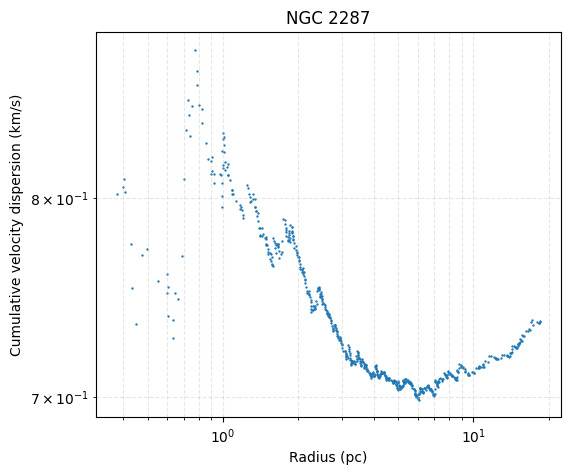


Processing: Collinder 69
Using centre:
 RA = 83.90255677309254
 DEC = 9.824382538996044
 Distance = 396
 Membership threshold = 0.9
Stars used: 787


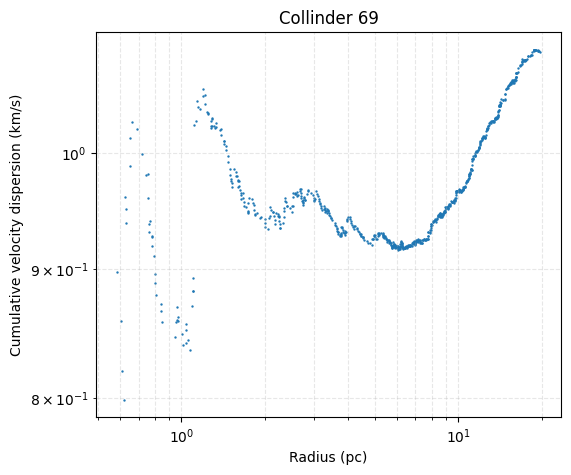


Processing: Collinder 261
Using centre:
 RA = 189.52159988571168
 DEC = -68.37964363076324
 Distance = 2634
 Membership threshold = 0.93
Stars used: 1910


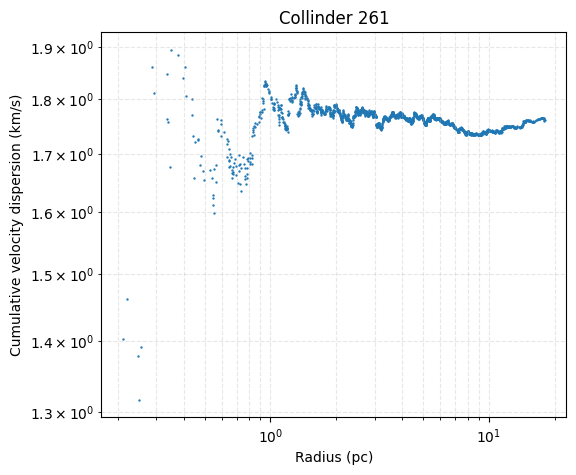


Processing: IC 4651
Using centre:
 RA = 261.1957361852442
 DEC = -49.919501983678735
 Distance = 908
 Membership threshold = 0.97
Stars used: 1360


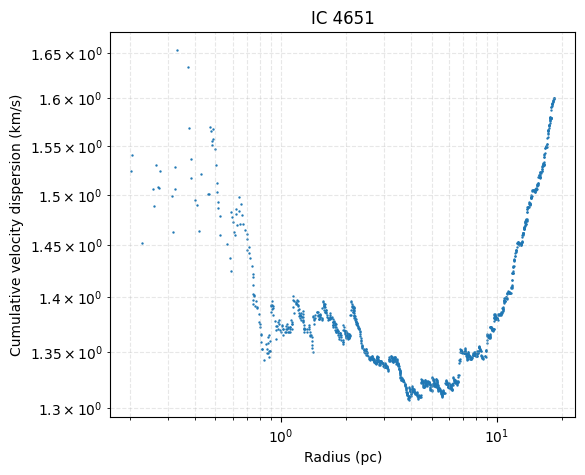


Processing: Melotte 20
Using centre:
 RA = 51.50290350555628
 DEC = 49.03709986634556
 Distance = 180
 Membership threshold = 0.94
Stars used: 580


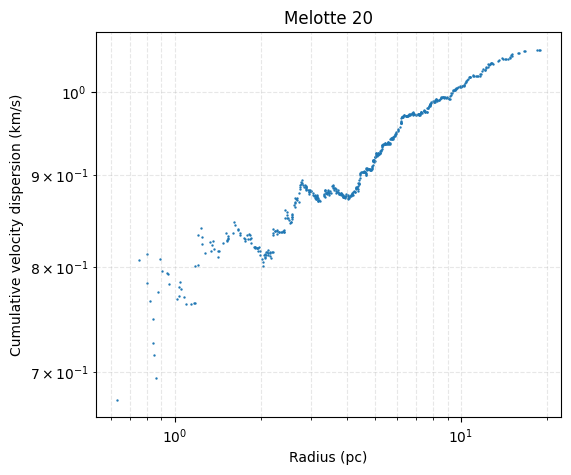


Processing: Melotte 22
Using centre:
 RA = 56.67062653779767
 DEC = 24.135321363262435
 Distance = 150
 Membership threshold = 0.95
Stars used: 1262


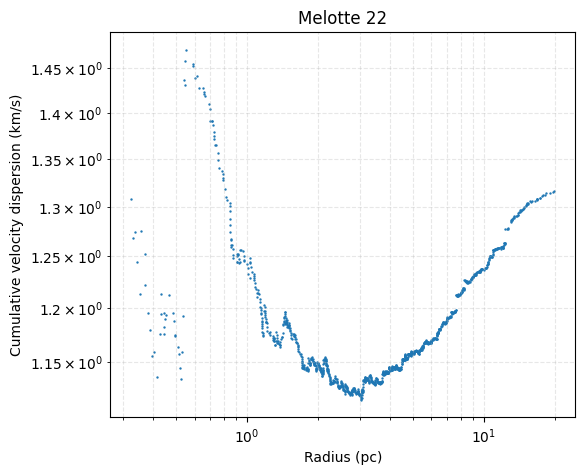


Processing: Melotte 101
Using centre:
 RA = 160.54278996957677
 DEC = -65.10873975686084
 Distance = 1728
 Membership threshold = 0.95
Stars used: 810


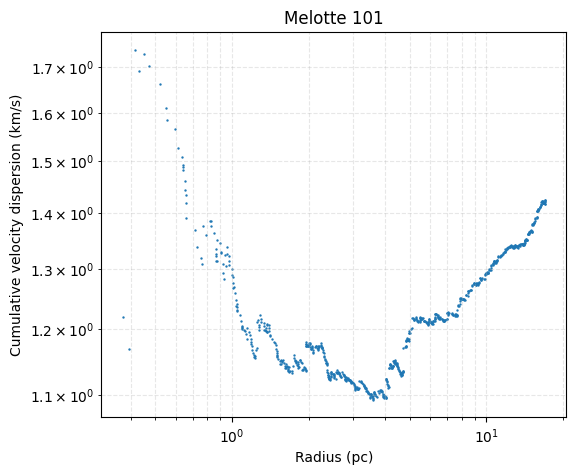


Processing: NGC 188
Using centre:
 RA = 11.796240494842191
 DEC = 85.24343472198291
 Distance = 1746
 Membership threshold = 0.95
Stars used: 905


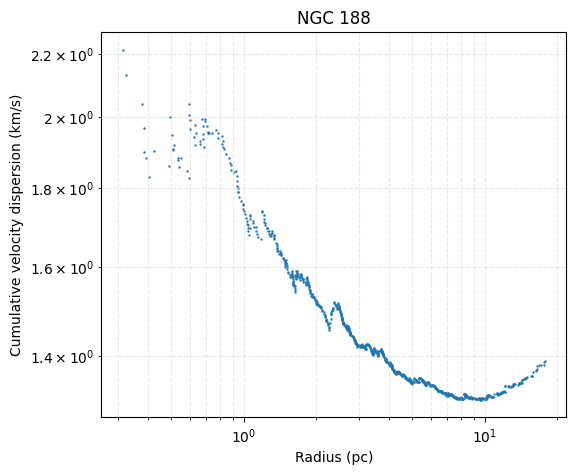


Processing: NGC 1039
Using centre:
 RA = 40.56434277608881
 DEC = 42.73797066768291
 Distance = 533
 Membership threshold = 0.94
Stars used: 710


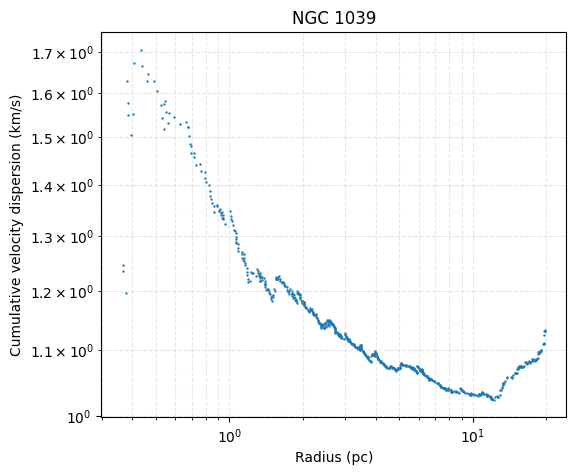


Processing: NGC 1647
Using centre:
 RA = 71.5057872821261
 DEC = 19.13775137120909
 Distance = 520
 Membership threshold = 0.94
Stars used: 688


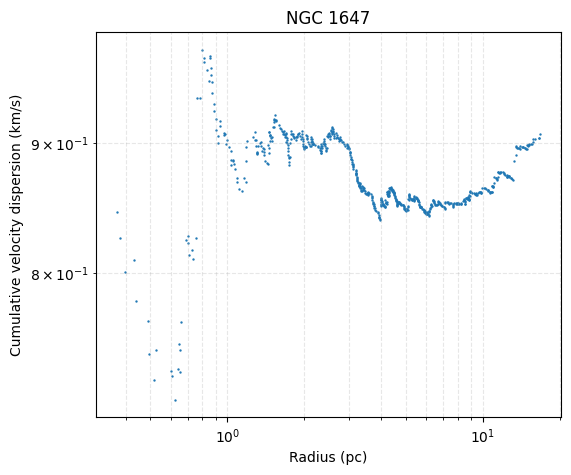


Processing: NGC 2112
Using centre:
 RA = 88.43409895633633
 DEC = 0.4050498557407779
 Distance = 778
 Membership threshold = 0.95
Stars used: 867


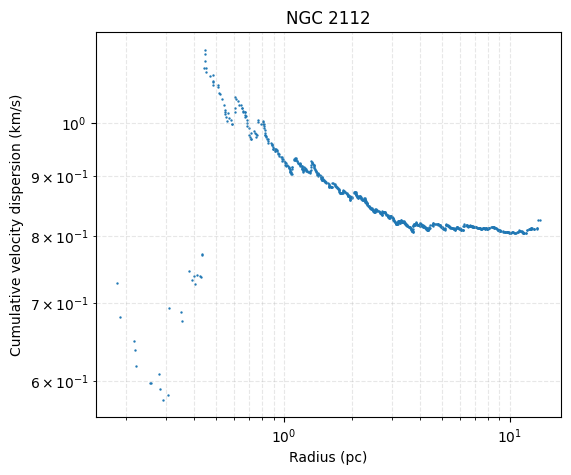


Processing: NGC 2477
Using centre:
 RA = 118.04076949863092
 DEC = -38.5344026741344
 Distance = 1263
 Membership threshold = 0.94
Stars used: 2696


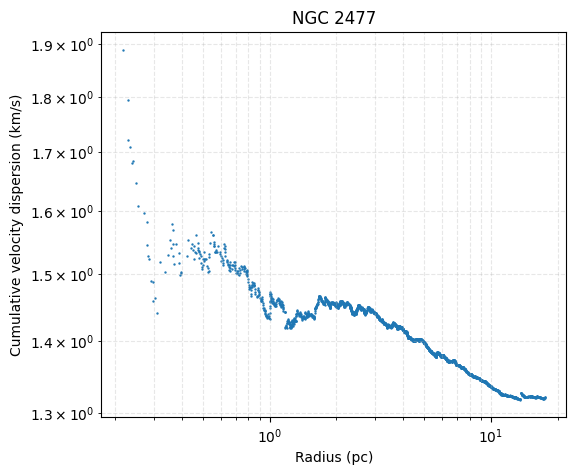


Processing: NGC 2516
Using centre:
 RA = 119.50629591278432
 DEC = -60.794174056278706
 Distance = 414
 Membership threshold = 0.95
Stars used: 1874


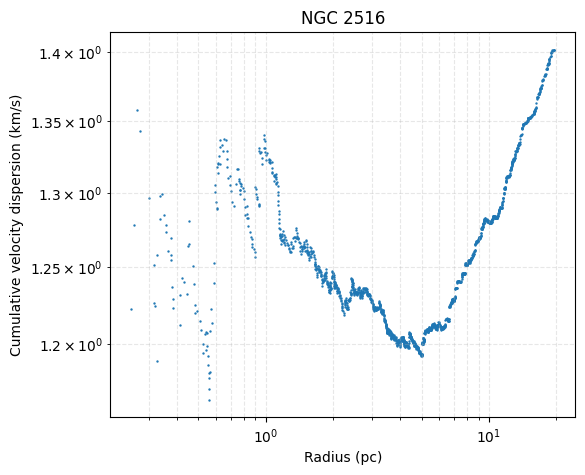


Processing: NGC 2539
Using centre:
 RA = 122.66827133944868
 DEC = -12.827348459616353
 Distance = 1176
 Membership threshold = 0.96
Stars used: 570


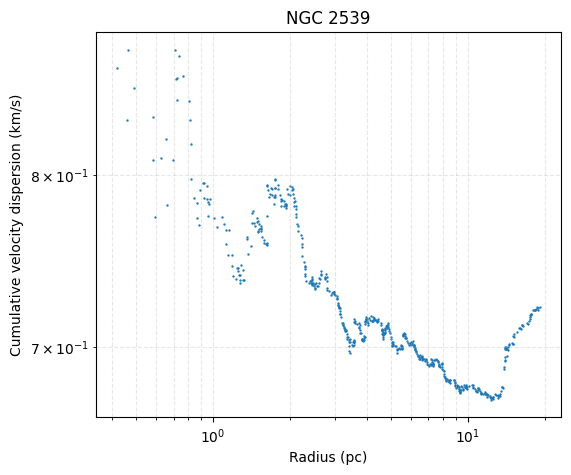


Processing: NGC 2632
Using centre:
 RA = 130.0694072360568
 DEC = 19.670765035450152
 Distance = 174
 Membership threshold = 0.93
Stars used: 730


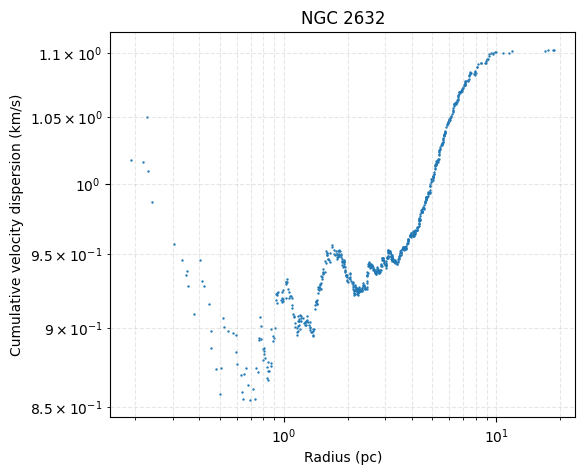


Processing: NGC 2682
Using centre:
 RA = 132.8443307419603
 DEC = 11.813859978133731
 Distance = 501
 Membership threshold = 0.93
Stars used: 1178


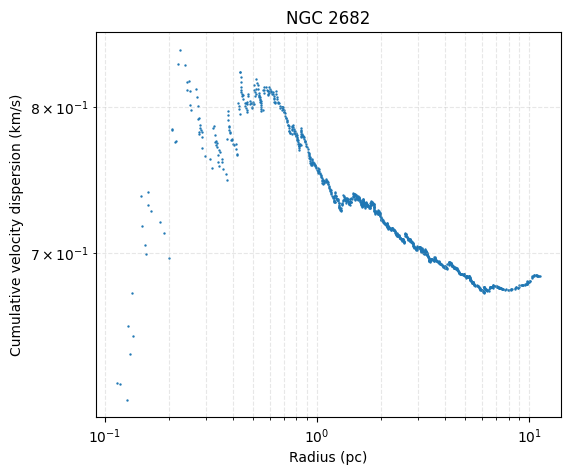


Processing: NGC 6124
Using centre:
 RA = 246.32248879942784
 DEC = -40.64089568926482
 Distance = 501
 Membership threshold = 0.95
Stars used: 1501


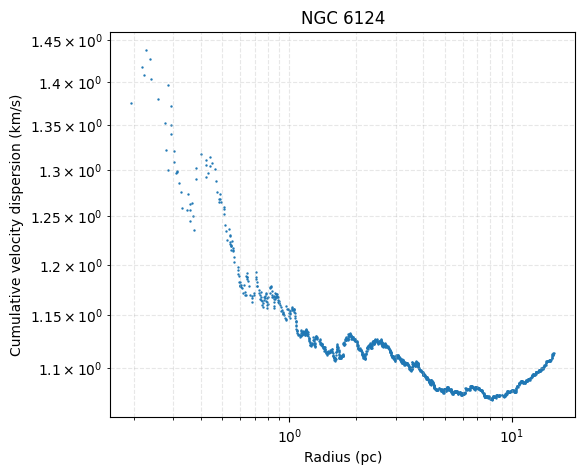


Processing: NGC 6819
Using centre:
 RA = 295.32336084172306
 DEC = 40.19199257170372
 Distance = 2056
 Membership threshold = 0.95
Stars used: 1689


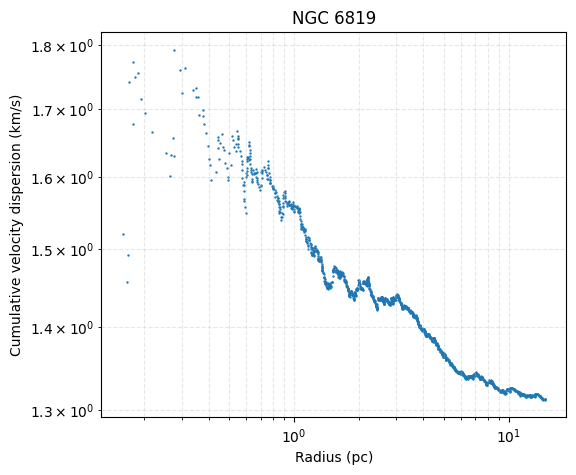


Processing: NGC 6939
Using centre:
 RA = 307.9129189346263
 DEC = 60.65168590931616
 Distance = 1422
 Membership threshold = 0.96
Stars used: 821


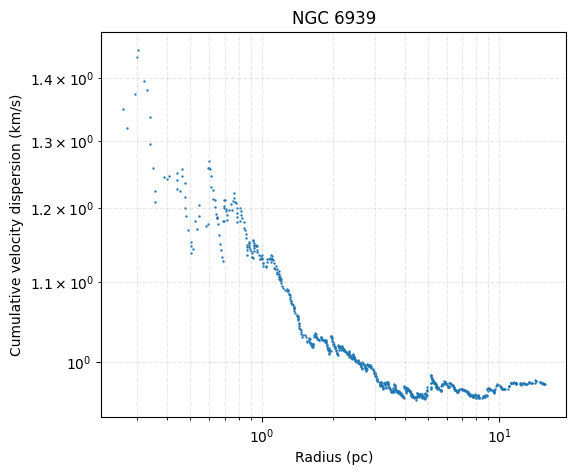


Processing: NGC 6940
Using centre:
 RA = 308.6137292750807
 DEC = 28.27482962589846
 Distance = 1061
 Membership threshold = 0.95
Stars used: 897


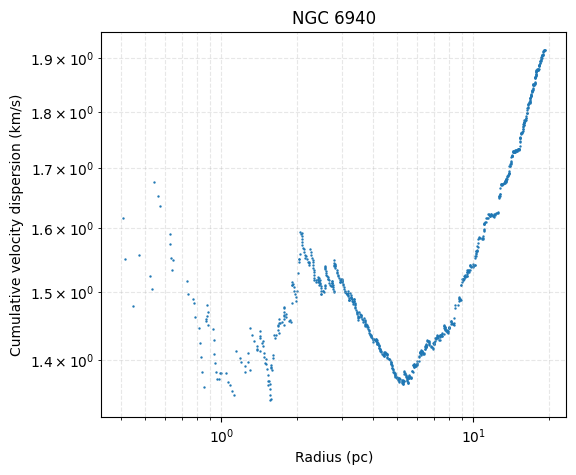


Processing: Ngc 7789
Using centre:
 RA = -0.6529881736290195
 DEC = 56.72350645451583
 Distance = 1421
 Membership threshold = 0.92
Stars used: 69


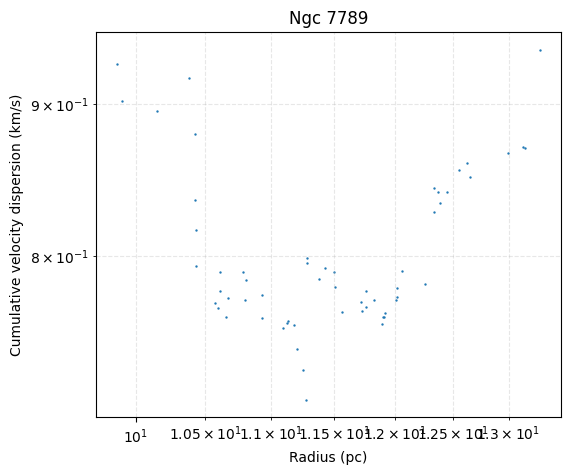

In [73]:
for cluster_name, file_path in cluster_files.items():

    print("\n====================================")
    print("Processing:", cluster_name)

    # =====================================================
    # LOAD DATA
    # =====================================================

    df = pd.read_csv(file_path)

    # =====================================================
    # GET PARAMETERS FROM RE-ESTIMATED CENTRES FILE (ROBUST)
    # =====================================================

    mask = (
        centres["Cluster"]
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace("_", " ")
        ==
        cluster_name.strip().lower().replace("_", " ")
    )

    if mask.sum() == 0:
        print(" Cluster NOT found in centres file:", cluster_name)
        continue   # ← this is valid because we are inside loop

    row = centres.loc[mask].iloc[0]

    ra0_deg  = row["RA_KDE_deg"]
    dec0_deg = row["Dec_KDE_deg"]
    distance_pc = row["distance_pc"]
    membership_threshold = row["Membership_threshold"]

    print("Using centre:")
    print(" RA =", ra0_deg)
    print(" DEC =", dec0_deg)
    print(" Distance =", distance_pc)
    print(" Membership threshold =", membership_threshold)

    # convert centre to radians  ← IMPORTANT (you removed this earlier)
    ra0  = np.deg2rad(ra0_deg)
    dec0 = np.deg2rad(dec0_deg)

    # =====================================================
    # COMPUTE PROJECTED RADIUS (pc)
    # =====================================================

    ra  = np.deg2rad(df["ra"].values)
    dec = np.deg2rad(df["dec"].values)

    delta_ra  = (ra - ra0) * np.cos(dec0)
    delta_dec = (dec - dec0)

    theta = np.sqrt(delta_ra**2 + delta_dec**2)
    df["r_pc"] = theta * distance_pc

    # =====================================================
    # MEMBERSHIP + RADIAL CUT
    # =====================================================

    df = df[df["cluster_membership"] > membership_threshold].copy()
    df = df[df["r_pc"] <= 20].copy()

    print("Stars used:", len(df))

    if len(df) < 10:
        print("Too few stars — skipping")
        continue

    # =====================================================
    # SORT BY RADIUS
    # =====================================================

    df = df.sort_values("r_pc").reset_index(drop=True)
    r = df["r_pc"].values

    # =====================================================
    # PROPER MOTION → VELOCITY
    # =====================================================

    k = 4.74047e-3 * distance_pc

    v_ra  = df["pmra"].values  * k
    v_dec = df["pmdec"].values * k

    err_ra  = df["pmra_error"].values  * k
    err_dec = df["pmdec_error"].values * k

    # =====================================================
    # CUMULATIVE DISPERSION
    # =====================================================

    sigma_cum = []
    min_stars = 10

    for i in range(min_stars, len(r)):

        sig_ra  = np.std(v_ra[:i],  ddof=1)
        sig_dec = np.std(v_dec[:i], ddof=1)

        err_ra2  = np.mean(err_ra[:i]**2)
        err_dec2 = np.mean(err_dec[:i]**2)

        sig_ra2_intr  = max(sig_ra**2  - err_ra2,  0)
        sig_dec2_intr = max(sig_dec**2 - err_dec2, 0)

        sigma_total = np.sqrt(sig_ra2_intr + sig_dec2_intr)
        sigma_cum.append(sigma_total)

    r_cum = r[min_stars:]

    # =====================================================
    # PLOT
    # =====================================================

    plt.figure(figsize=(6,5))
    plt.scatter(r_cum, sigma_cum, s=0.5)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Radius (pc)")
    plt.ylabel("Cumulative velocity dispersion (km/s)")
    plt.title(cluster_name)
    plt.grid(True, which="both", ls="--", alpha=0.3)
    plt.show()